In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow import keras 

In [3]:
from tensorflow.keras import Sequential

In [5]:
train_df = pd.read_csv("Training_set.csv")
test_df = pd.read_csv("Testing_set.csv")


In [6]:
print(train_df.head())
print(test_df.head())

      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART
      filename
0  Image_1.jpg
1  Image_2.jpg
2  Image_3.jpg
3  Image_4.jpg
4  Image_5.jpg


In [7]:
train_df.isnull().sum()

filename    0
label       0
dtype: int64

In [8]:
test_df.isnull().sum()

filename    0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
y = train_df["label"]

In [11]:

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [12]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [21]:
import numpy as np
import cv2
import os

IMG_SIZE = 128

X = []
y = []

for i, row in train_df.iterrows():
    path = os.path.join("train_images", row["filename"])

    img = cv2.imread(path)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0  # normalize

    X.append(img)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

[ WARN:0@0.013] global loadsave.cpp:278 findDecoder imread_('train_images/Image_1.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [16]:
pip3 install cv2

SyntaxError: invalid syntax (1799372846.py, line 1)

In [22]:
import os

path = "train_images/Image_1.jpg"
print(os.path.exists(path))

False


In [23]:
import os
print(os.getcwd())

/Users/sadhanauprety/Desktop/DL/NN/CNN/archive


In [24]:
import os

print(os.listdir("/Users/sadhanauprety/Desktop/DL/NN/CNN/archive"))

['test', 'Testing_set.csv', 'Training_set.csv', 'Image.ipynb', 'train', '.ipynb_checkpoints']


In [25]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

X = []
y = []

for i, row in train_df.iterrows():
    path = os.path.join("train", row["filename"])  # 👈 FIX HERE

    img = cv2.imread(path)

    if img is None:
        print("Broken:", path)
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(set(y_train)), activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)
    epochs=10,
    batch_size=32
)

ValueError: Invalid dtype: str800

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(train_df["label"])

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,   
    test_size=0.2,
    random_state=42
)

In [34]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.0625 - loss: 4.0160 - val_accuracy: 0.2115 - val_loss: 3.2564
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 152ms/step - accuracy: 0.2385 - loss: 2.9844 - val_accuracy: 0.3654 - val_loss: 2.5342
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 157ms/step - accuracy: 0.4241 - loss: 2.1472 - val_accuracy: 0.4808 - val_loss: 2.0552
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.5795 - loss: 1.5370 - val_accuracy: 0.5169 - val_loss: 1.8558
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 163ms/step - accuracy: 0.6965 - loss: 1.0351 - val_accuracy: 0.5108 - val_loss: 1.9101
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.7803 - loss: 0.7355 - val_accuracy: 0.5446 - val_loss: 1.8859
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - accuracy: 0.8242 - loss: 0.5790 - val_accuracy: 0.5446 - val_loss: 2.0948
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 172ms/step - accuracy: 0.8709 - loss: 0

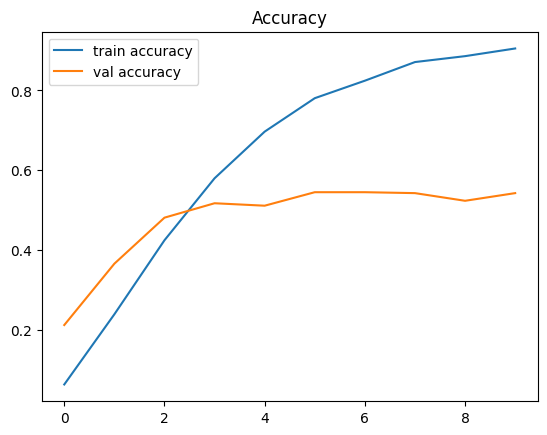

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

In [36]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5423 - loss: 2.4243
Validation Accuracy: 0.5423076748847961


In [38]:
pred = model.predict(X_val)
pred_classes = pred.argmax(axis=1)
pred_labels = le.inverse_transform(pred_classes)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
